<a href="https://colab.research.google.com/github/Adithyasajeev22/Machine-Learning/blob/main/CONFUSION_MATRIX_(CLASSIFICATION)_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CONFUSION MATRIX -CLASSIFICATION**

# 1.LOAD AND DISPLAY THE DATASET

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/BREAST CANCER.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 2.UNDERSTAND THE DATA TYPES AND SUMMARY

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

# 3.DATA CLEANING

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# 4.VISUALIZATION

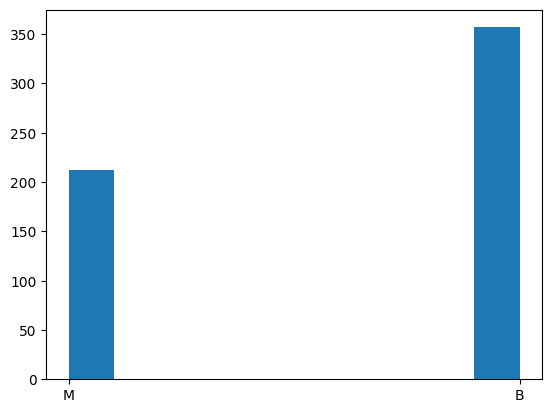

In [ ]:
plt.hist(df['diagnosis'])
plt.show()

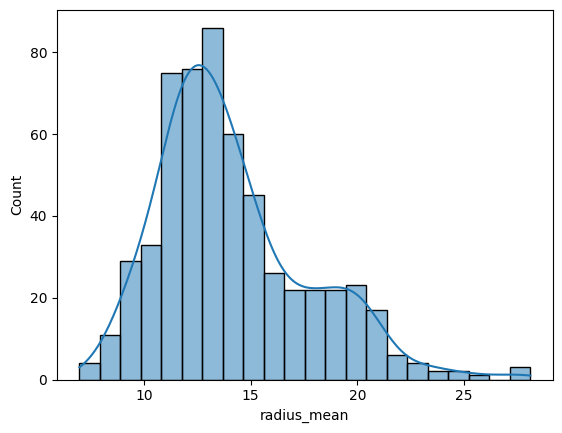

In [ ]:
sns.histplot(df['radius_mean'],kde=True)
plt.show()

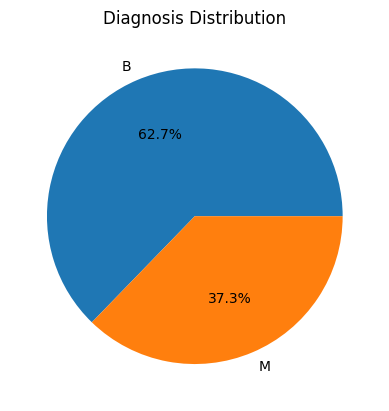

In [ ]:
plt.figure()
df['diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Diagnosis Distribution')
plt.ylabel('')
plt.show()

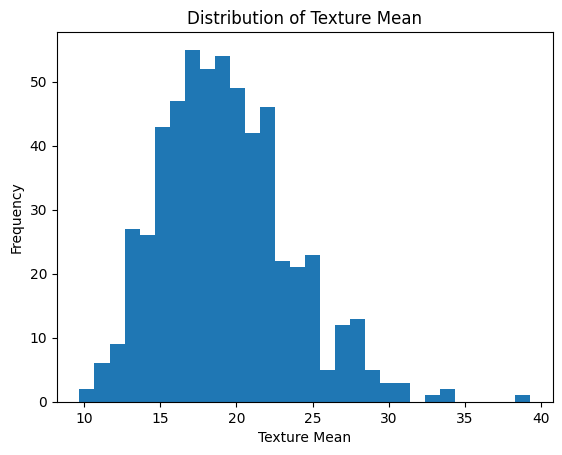

In [ ]:
plt.figure()
plt.hist(df['texture_mean'], bins=30)
plt.title('Distribution of Texture Mean')
plt.xlabel('Texture Mean')
plt.ylabel('Frequency')
plt.show()

# 5.CORRELATION ANALYSIS IN EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
print(df['diagnosis'].unique()) #nominal

['M' 'B']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['diagnosis']=le.fit_transform(df['diagnosis'])

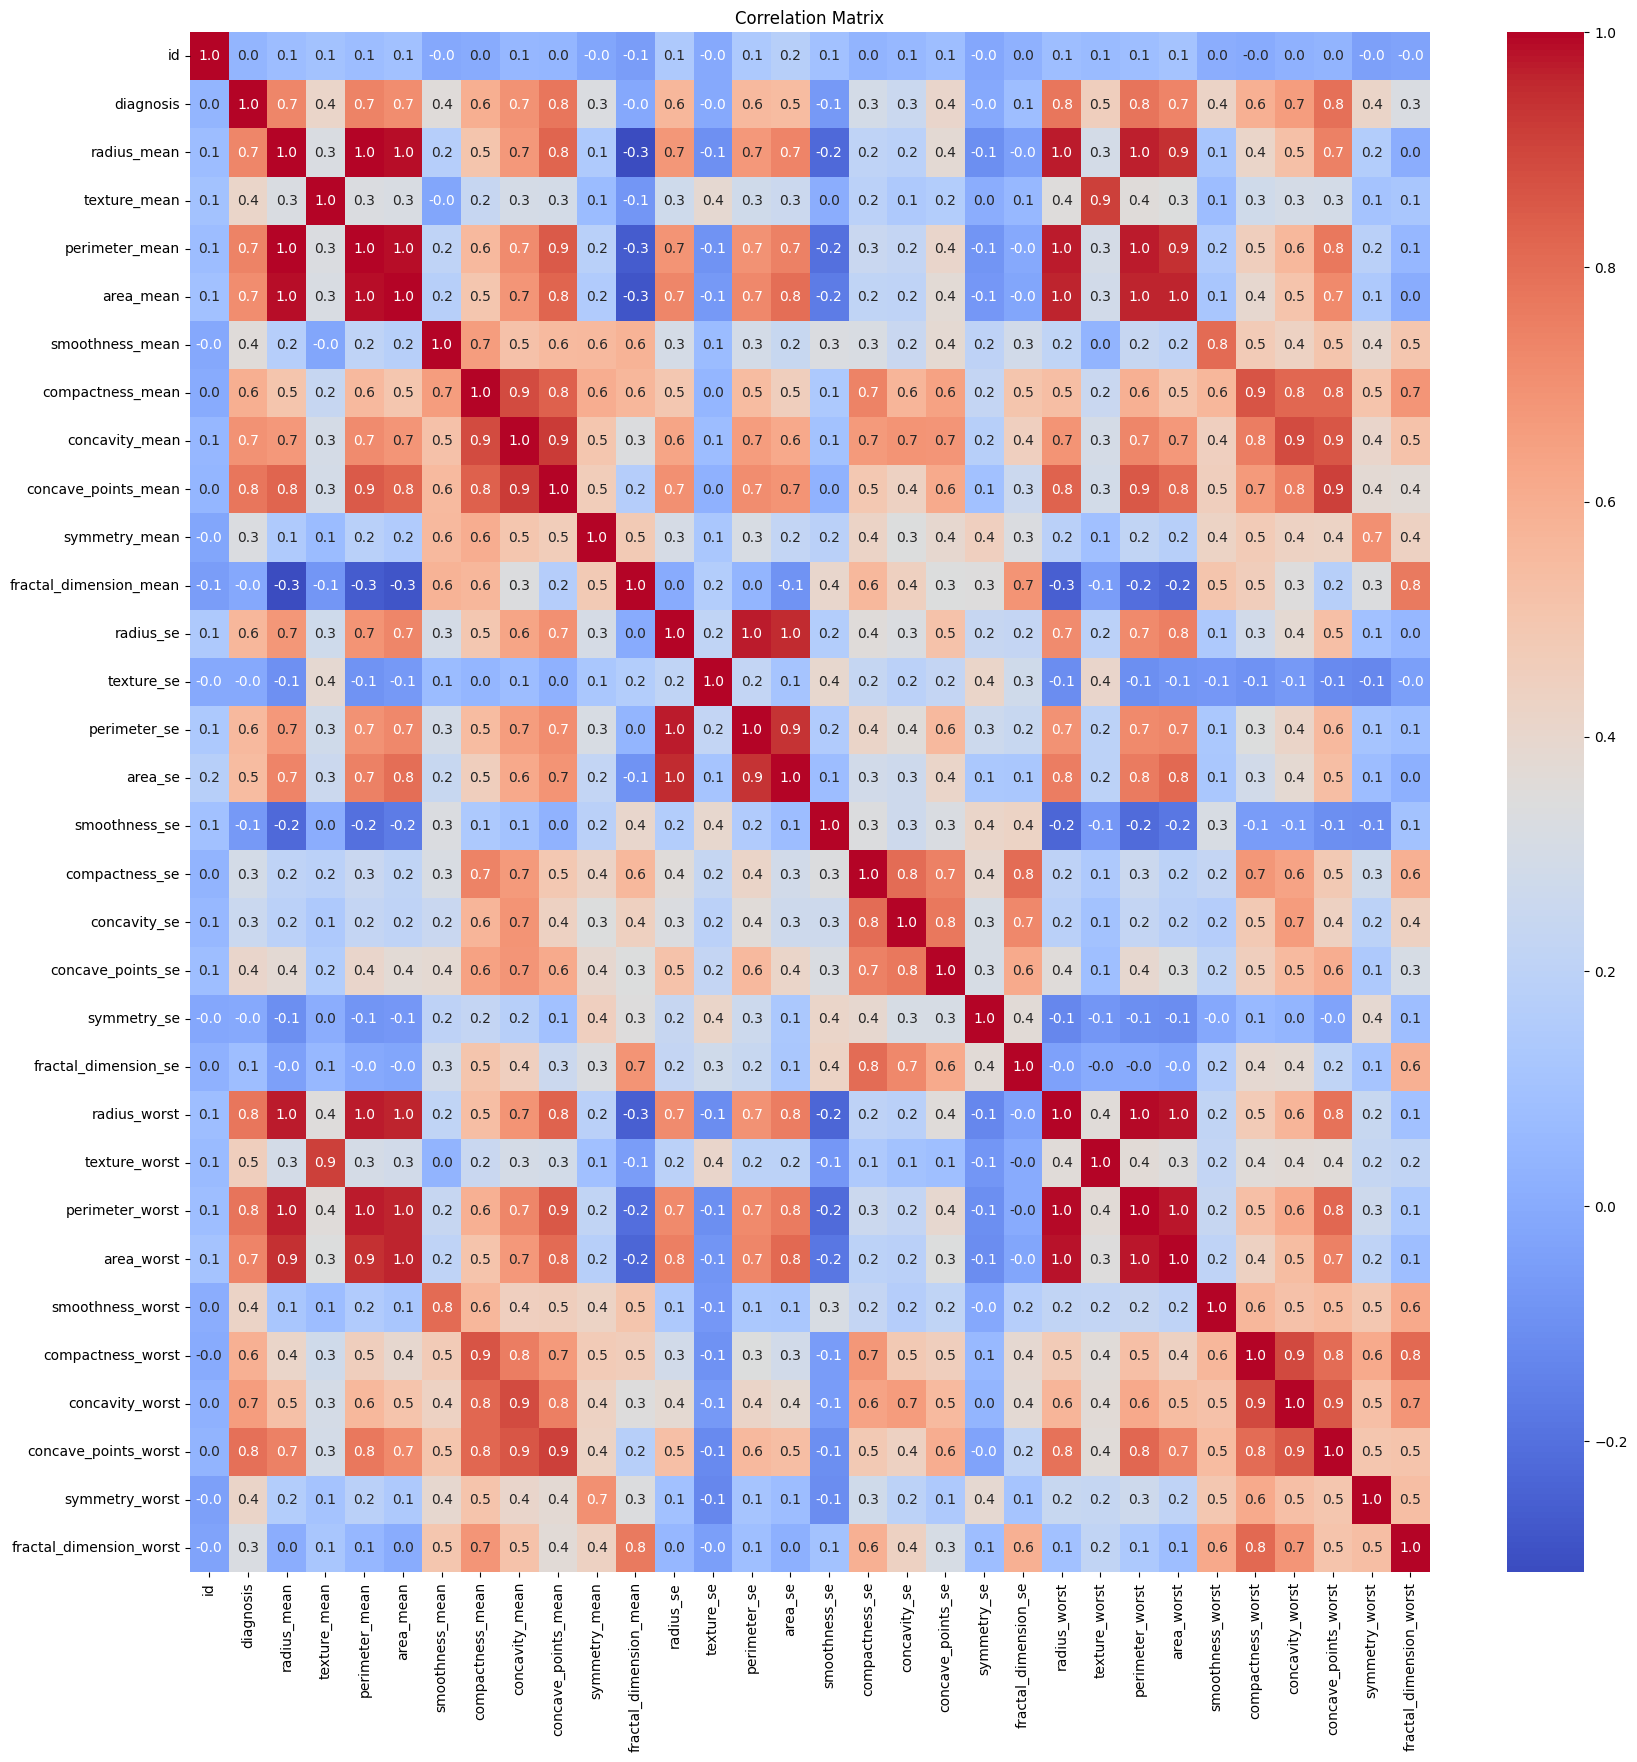

In [ ]:
corr_matrix=df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0


In [ ]:
df.shape

(569, 32)

In [ ]:
df.drop(['radius_mean','area_worst','concave_points_worst','concavity_worst','compactness_worst','perimeter_worst','texture_worst','area_se','perimeter_se','radius_se','concave_points_mean','concavity_mean','compactness_mean','area_mean','texture_mean','perimeter_mean'],axis=1,inplace=True)

In [ ]:
df.shape

(569, 16)

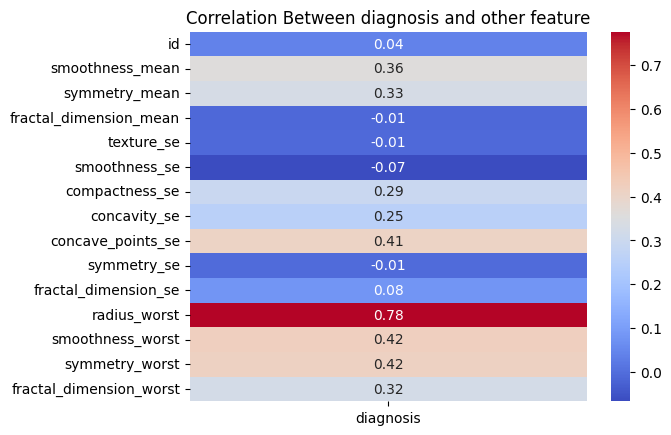

In [ ]:
status_corr=df.corr()['diagnosis']
status_corr=status_corr.drop('diagnosis')

sns.heatmap(status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation Between diagnosis and other feature')
plt.show()

In [ ]:
df.shape

(569, 16)

In [ ]:
df.drop(['fractal_dimension_mean','texture_se','symmetry_se'],axis=1,inplace=True)

In [ ]:
df.shape

(569, 13)

# 6.OUTLIER CHECKING AND REMOVING

<Axes: >

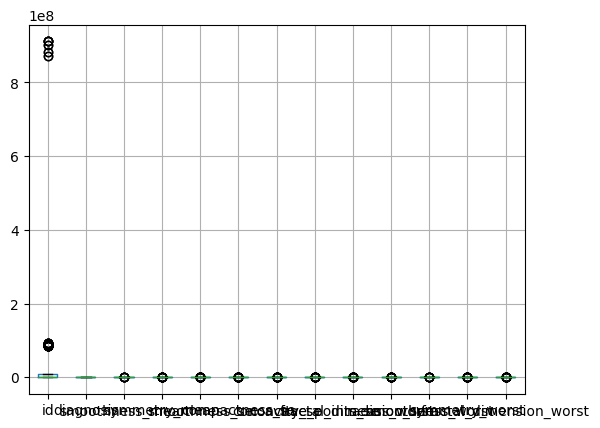

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col] >=lower_bound)& (df[col] <=upper_bound)]
  return df

df_cleaned=remove_outliers_iqr(df,exclude_column='diagnosis')
df=df_cleaned

In [ ]:
df.shape

(366, 13)

# 7.DATA SCALING

In [ ]:
df

,id,diagnosis,smoothness_mean,symmetry_mean,smoothness_se,compactness_se,concavity_se,concave_points_se,fractal_dimension_se,radius_worst,smoothness_worst,symmetry_worst,fractal_dimension_worst
1,842517,1,0.08474,0.1812,0.005225,0.013080,0.01860,0.013400,0.003532,24.99,0.1238,0.2750,0.08902
6,844359,1,0.09463,0.1794,0.004314,0.013820,0.02254,0.010390,0.002179,22.88,0.1442,0.3063,0.08368
10,845636,1,0.08206,0.1528,0.004029,0.009269,0.01101,0.007591,0.003042,19.19,0.1181,0.2948,0.08452
13,846381,1,0.08401,0.1847,0.009769,0.031260,0.05051,0.019920,0.003002,16.84,0.1131,0.2809,0.06287
16,848406,1,0.09867,0.1586,0.005718,0.011620,0.01998,0.011090,0.002085,19.07,0.1464,0.3029,0.08216
...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,925277,0,0.08473,0.1454,0.004242,0.046390,0.06578,0.016060,0.004406,15.48,0.1026,0.2258,0.08004
559,925291,0,0.09261,0.1388,0.008200,0.029820,0.05738,0.012670,0.004738,12.48,0.1298,0.2112,0.08732
560,925292,0,0.09929,0.1537,0.007256,0.026780,0.02071,0.016260,0.005304,15.30,0.1241,0.2250,0.08321
565,926682,1,0.09780,0.1752,0.005769,0.024230,0.03950,0.016780,0.002498,23.69,0.1166,0.2572,0.06637


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['id','smoothness_mean','smoothness_se','compactness_se','concavity_se','concave_points_se','fractal_dimension_se','radius_worst','smoothness_worst','symmetry_worst','fractal_dimension_worst']

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

# 8.PREDICT ACCURACY

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['id','smoothness_mean','smoothness_se','compactness_se','concavity_se','concave_points_se','fractal_dimension_se','radius_worst','smoothness_worst','symmetry_worst','fractal_dimension_worst']]
y=df['diagnosis']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.74


# 9.CONFUSION MATRIX

<Figure size 2000x700 with 0 Axes>

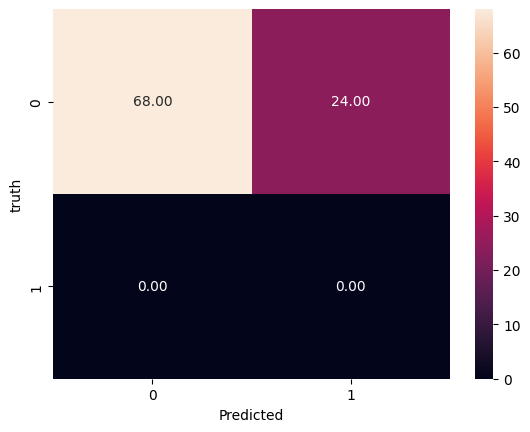

<Figure size 2000x700 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix
y_predicted=model.predict(x_test)
y_predicted

cm=confusion_matrix(y_predicted,y_test)
cm

import seaborn as sn
sn.heatmap(cm,fmt=".2f",annot=True)
plt.xlabel('Predicted')
plt.ylabel('truth')
plt.figure(figsize=(20,7))